In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import os
from nltk.tokenize import word_tokenize
from pathlib import Path

In [5]:
#Path definitions
PATH_TRAIN = "D:/scientific_nlp_from_scratch/03_toxhabits_ner_bilstm/data/ToxNER/ToxHabits(ToxNER)_Train_ANNFiles/train_annotations"
PATH_TEST = "D:/scientific_nlp_from_scratch/03_toxhabits_ner_bilstm/data/ToxNER/ToxHabits(ToxNER)_Test_ANNFiles/test_good"

### INITIAL LOADERS FOR DATA

In [6]:
#filenames extraction

train_filenames = []
with os.scandir(PATH_TRAIN) as train_set:
    for file in train_set:
        if file.is_file() and file.name.endswith('.txt'):
            train_filenames.append(file.name.split(".")[0])

test_filenames = []
with os.scandir(PATH_TEST) as test_set:
    for file in test_set:
        if file.is_file() and file.name.endswith('.txt'):
            test_filenames.append(file.name.split(".")[0])

train_filenames.sort()
test_filenames.sort()

In [7]:
#loop for extraction of particular train sample

def extract_sample(filename):
    if filename not in train_filenames:
        raise ValueError(f"Filename '{filename}' not found in the training set!")
    with open(os.path.join(PATH_TRAIN, filename + ".txt"), encoding="utf-8") as f1:
        text = f1.read()
    annotations = []

    with open(os.path.join(PATH_TRAIN, filename + ".ann"), encoding="utf-8") as f2:
        for line in f2:
            line = line.rstrip("\n")

            if not line:
                continue

            annotation_id, span_info, annotation_text = line.split("\t", maxsplit=2)
            label, start, end = span_info.split()

            annotation = {
                "id": annotation_id,
                "label": label,
                "start": int(start),
                "end": int(end),
                "text": annotation_text
            }

            annotations.append(annotation)

    return text, annotations


#### EXPLORATORY DATA ANALYSIS

In [8]:
#for each .txt should be corresponding .ann, how many empty
ann_counter = 0
empty_ann = 0
for filename in train_filenames:
    filepath = Path(PATH_TRAIN + "/" + filename + ".ann")
    if not filepath.is_file():
        print(f"No annotation for file {filename}!")
    else:
        ann_counter += 1
    with open(filepath, "r", encoding="utf-8") as f1:
        if not f1.read().strip():
            empty_ann += 1
#annotations without text checking
assert ann_counter == len(train_filenames)

#how many negative samples (empty .ann files):
print(f"Empty .ann files: {empty_ann}")

Empty .ann files: 31


In [9]:
#duplicate checking
from collections import defaultdict

text_to_files = defaultdict(list)

for filename in train_filenames:
    txt_path = Path(PATH_TRAIN) / f"{filename}.txt"
    
    if txt_path.is_file():
        text = txt_path.read_text(encoding="utf-8").strip()
        text_to_files[text].append(filename)

duplicates = {
    text: files
    for text, files in text_to_files.items()
    if len(files) > 1
}

print(f"Number of duplicate groups: {len(duplicates)}")
print(f"Number of duplicated documents: {sum(len(files) for files in duplicates.values())}")

for text, files in list(duplicates.items())[:10]:
    print(files)


Number of duplicate groups: 1
Number of duplicated documents: 2
['S1130-01082017000300022-1', 'cc_habitos_toxicos39']


In [10]:
#Annotation checking

for filename in train_filenames:
    text, annotations = extract_sample(filename)
    if annotations:
        for annotation in annotations:
            start_idx = annotation["start"]
            end_idx = annotation["end"]
            if text[start_idx:end_idx] != annotation["text"]:
                print(f"ERROR in label mapping for file {filename}!")
            
            if annotation["label"] not in ["Tobacco", "Drug", "Cannabis", "Alcohol"]:
                print(f"ERROR in label naming for file {filename}!")

In [11]:
#Labels stats and distributions (в одном доке может быть множество упоминаний одного класса)
num_ann_per_doc = []
total_per_class = {"Tobacco" : 0, "Drug" : 0, "Cannabis" : 0, "Alcohol" : 0}
docs_per_class = {"Tobacco" : 0, "Drug" : 0, "Cannabis" : 0, "Alcohol" : 0}

for filename in train_filenames:
    text, annotations = extract_sample(filename)
    num_ann_per_doc.append(len(annotations))
    if annotations:
        doc_buffer = {"Tobacco" : False, "Drug" : False, "Cannabis" : False, "Alcohol" : False}
        for annotation in annotations:
            total_per_class[annotation["label"]] += 1
            if not doc_buffer[annotation["label"]]:
                doc_buffer[annotation["label"]] = True
                docs_per_class[annotation["label"]] += 1


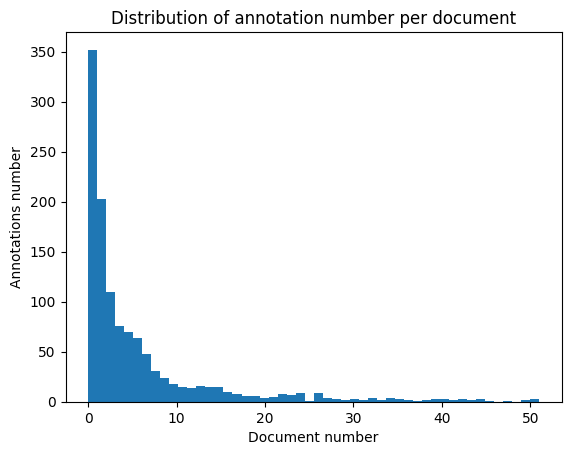

In [12]:
#annotation number per document
plt.hist(num_ann_per_doc, bins = 50)
plt.xlabel("Document number")
plt.ylabel("Annotations number")
plt.title("Distribution of annotation number per document")
plt.show()

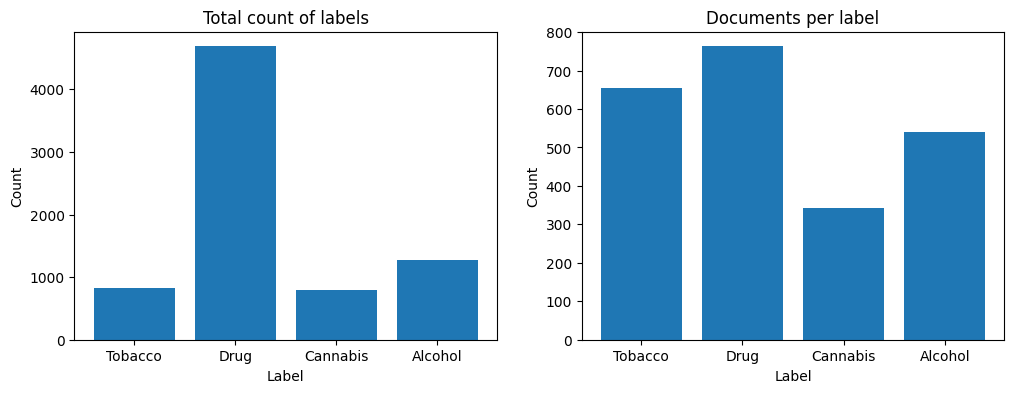

In [13]:
#total label stats
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(list(total_per_class.keys()), list(total_per_class.values()))
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Label")
axes[0].set_title("Total count of labels")

axes[1].bar(list(docs_per_class.keys()), list(docs_per_class.values()))
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Label")
axes[1].set_title("Documents per label")

plt.show()

In [28]:
#General semantic view on samples
import random
idx = random.randint(0,len(train_filenames)+1)

test_text, annotation = extract_sample(train_filenames[idx])
print(test_text)
print("-"*100)
for ann in annotation:
    print(ann)

Varón de 54 años. Vive en Madrid. Trabaja como electricista. No tiene pareja estable. HSH con relaciones sexuales de riesgo, sin uso de preservativo. Exfumador de aprox 5 paq/año.
• Infección VIH diagnosticada hace 5 años (estadio A1). Desde el inicio, en tratamiento con DTG/ABC/3TC, con buen control inmunovirológico (Octubre 2019: CV VIH < 37 copias/ml y CD4: 668 cel/mcl; CD4/CD8 1.03). No otros antecedentes de interés.
• Hoy acude a consulta. La última vez no pudo venir por encontrarse en una sesión de sauna, en la que consumió mefredrona durante 4 días. Desde entonces refiere ardor leve en pene, no secreción uretral. Durante esos días no tomó el TAR. Ahora se encuentra deprimido, con aspecto descuidado.
• Nos confirma que no consume mefedrona iv, éxtasis, cocaína, GHB, pero sí ocasionalmente poppers inhalados.
----------------------------------------------------------------------------------------------------
{'id': 'T1', 'label': 'Tobacco', 'start': 150, 'end': 159, 'text': 'Exfuma

In [173]:
#Tokenizer
import spacy

nlp = spacy.load("es_core_news_sm")
doc = nlp(test_text)

from spacy.language import Language
ABBREVIATIONS = {
    "comp",
    "comps",
    "dr",
    "dra",
    "mg",
    "ml"
}


@Language.component("fix_medical_sentence_boundaries")
def fix_medical_sentence_boundaries(doc):
    for i, token in enumerate(doc[:-1]):
        #["comps.", "de"]
        if (
            token.text.endswith(".")
            and token.text[:-1].lower() in ABBREVIATIONS
        ):
            doc[i + 1].is_sent_start = False

        #["comps", ".", "de"]
        if (
            token.text == "."
            and i > 0
            and doc[i - 1].lower_ in ABBREVIATIONS
        ):
            doc[i + 1].is_sent_start = False

    return doc


nlp.add_pipe(
    "fix_medical_sentence_boundaries",
    before="parser"
)


def tokenize(text):
    doc = nlp(text)
    return [token.text for token in doc]

In [41]:
#text symbol and tokenized length
gen_len = []
token_len = []
for filename in train_filenames:
    text, annotation = extract_sample(filename)
    gen_len.append(len(text))
    token_len.append(len(tokenize(text)))


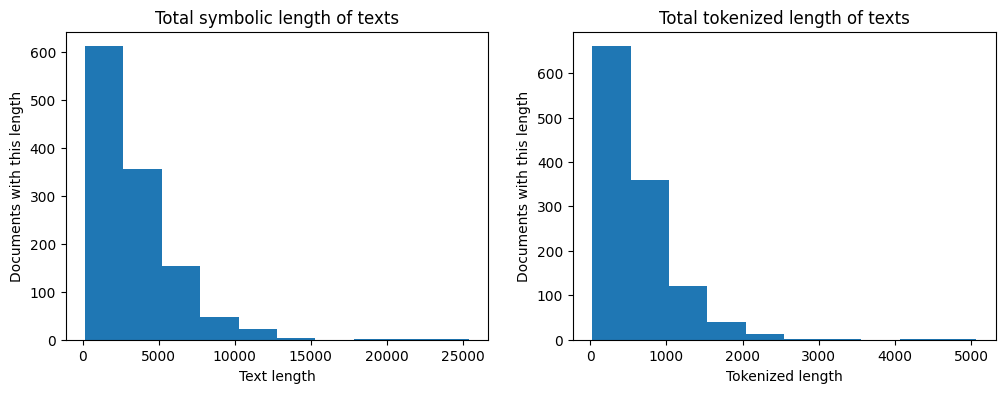

Average tokenized length: 617.4837364470392
Average symbolic length: 3458.2410341951627

75% percentile of tokenized length: 808.0
95% percentile of tokenized length: 1526.1
99% percentile of tokenized length: 2181.5399999999995
95% percentile of symbolic length: 8504.899999999996


In [155]:
#plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gen_len)
axes[0].set_ylabel("Documents with this length")
axes[0].set_xlabel("Text length")
axes[0].set_title("Total symbolic length of texts")

axes[1].hist(token_len)
axes[1].set_ylabel("Documents with this length")
axes[1].set_xlabel("Tokenized length")
axes[1].set_title("Total tokenized length of texts")

plt.show()

print(f"Average tokenized length: {np.mean((token_len))}")
print(f"Average symbolic length: {np.mean((gen_len))}\n")

print(f"75% percentile of tokenized length: {np.percentile(token_len, [75])[0]}")
print(f"95% percentile of tokenized length: {np.percentile(token_len, [95])[0]}")
print(f"99% percentile of tokenized length: {np.percentile(token_len, [99])[0]}")
print(f"95% percentile of symbolic length: {np.percentile(gen_len, [95])[0]}")


In [72]:
def tokenize_idx(text):
    doc = nlp(text)
    return [(token.text, token.idx, token.idx + len(token.text)) for token in doc]


In [84]:
multi_labels = 0
for filename in train_filenames:
    text, annotations = extract_sample(filename)
    for annotation in annotations:
        if len(tokenize(annotation["text"]))>1:
            #print("ACTUAL LABEL:",annotation["label"], " TEXT:", annotation["text"])
            multi_labels += 1

print(f"Amount of multiword labels:{multi_labels}")

Amount of multiword labels:730


### FROM BRAT TO BIO MAPPING

In [158]:
def build_bio_sample(filename):
    text, annotations = extract_sample(filename)
    tokenized_text = tokenize_idx(text)

    bio_tags = ["O"] * len(tokenized_text)

    for annotation in annotations:
        label = annotation["label"]
        start = annotation["start"]
        end = annotation["end"]

        first_token = True

        for i, token in enumerate(tokenized_text):
            token_start = token[1]
            token_end = token[2]

            if token_start >= start and token_end <= end:
                if first_token:
                    bio_tags[i] = f"B-{label}"
                    first_token = False
                else:
                    bio_tags[i] = f"I-{label}"

    tokens = [token[0] for token in tokenized_text]
    assert len(tokens) == len(bio_tags)

    return filename, tokens, bio_tags

In [174]:
sentence_lengths = []
cross_sentence_entities = []

for filename in train_filenames:
    text, annotations = extract_sample(filename)
    doc = nlp(text)

    sent_spans = [(sent.start_char, sent.end_char) for sent in doc.sents]
    sentence_lengths.extend(len(sent) for sent in doc.sents)

    for ann in annotations:
        ann_start = ann["start"]
        ann_end = ann["end"]

        covered_sent_ids = []
        for i, (sent_start, sent_end) in enumerate(sent_spans):
            if ann_start < sent_end and ann_end > sent_start:
                covered_sent_ids.append(i)

        if len(covered_sent_ids) > 1:
            cross_sentence_entities.append({
                "filename": filename,
                "label": ann["label"],
                "start": ann_start,
                "end": ann_end,
                "text": text[ann_start:ann_end],
                "sentence_ids": covered_sent_ids,
            })

print("Max sentence length:", max(sentence_lengths))
print("95 percentile:", np.percentile(sentence_lengths, 95))
print("99 percentile:", np.percentile(sentence_lengths, 99))
print("Entities crossing sentence boundaries:", len(cross_sentence_entities))


Max sentence length: 317
95 percentile: 55.0
99 percentile: 87.0
Entities crossing sentence boundaries: 0


In [ ]:
def build_bio_chunks(filename, max_tokens):
    _, tokens, bio_tags = build_bio_sample(filename)
    text, _ = extract_sample(filename)
    doc = nlp(text)
    tokenized_text = tokenize_idx(text)

    assert len(tokens) == len(tokenized_text) == len(bio_tags)

    sentence_data = []
    token_ptr = 0

    for sent in doc.sents:
        sent_start = sent.start_char
        sent_end = sent.end_char

        sent_tokens = []
        sent_offsets = []
        sent_tags = []

        while token_ptr < len(tokenized_text):
            token_text, token_start, token_end = tokenized_text[token_ptr]

            if token_start >= sent_end:
                break

            if token_start >= sent_start and token_end <= sent_end:
                sent_tokens.append(tokens[token_ptr])
                sent_offsets.append((token_start, token_end))
                sent_tags.append(bio_tags[token_ptr])

            token_ptr += 1

        if sent_tokens:
            sentence_data.append({
                "start": sent_start,
                "end": sent_end,
                "tokens": sent_tokens,
                "offsets": sent_offsets,
                "bio_tags": sent_tags,
            })

    chunks = []
    current_sentences = []
    current_len = 0

    for sent in sentence_data:
        sent_len = len(sent["tokens"])

        if current_sentences and current_len + sent_len > max_tokens:
            chunk_start = current_sentences[0]["start"]
            chunk_end = current_sentences[-1]["end"]

            chunk_tokens = []
            chunk_offsets = []
            chunk_tags = []

            for s in current_sentences:
                chunk_tokens.extend(s["tokens"])
                chunk_offsets.extend(s["offsets"])
                chunk_tags.extend(s["bio_tags"])

            chunks.append({
                "filename": filename,
                "text": text[chunk_start:chunk_end],
                "start": chunk_start,
                "end": chunk_end,
                "tokens": chunk_tokens,
                "offsets": chunk_offsets,
                "bio_tags": chunk_tags,
            })

            current_sentences = []
            current_len = 0

        current_sentences.append(sent)
        current_len += sent_len

    if current_sentences:
        chunk_start = current_sentences[0]["start"]
        chunk_end = current_sentences[-1]["end"]

        chunk_tokens = []
        chunk_offsets = []
        chunk_tags = []

        for s in current_sentences:
            chunk_tokens.extend(s["tokens"])
            chunk_offsets.extend(s["offsets"])
            chunk_tags.extend(s["bio_tags"])

        chunks.append({
            "filename": filename,
            "text": text[chunk_start:chunk_end],
            "start": chunk_start,
            "end": chunk_end,
            "tokens": chunk_tokens,
            "offsets": chunk_offsets,
            "bio_tags": chunk_tags,
        })

    return chunks

### TRAIN-TEST SPLIT

In [179]:
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

LABELS = ["Tobacco", "Drug", "Cannabis", "Alcohol"]

def build_doc_label_matrix(filenames):
    rows = []

    for filename in filenames:
        text, annotations = extract_sample(filename)

        present_labels = {label: 0 for label in LABELS}
        for ann in annotations:
            if ann["label"] in present_labels:
                present_labels[ann["label"]] = 1

        rows.append({
            "filename": filename,
            **present_labels
        })

    return pd.DataFrame(rows)


def multilabel_train_val_test_split(
    filenames,
    test_size=0.1,
    val_size=0.1,
    random_state=42
):
    df = build_doc_label_matrix(filenames)

    X = df["filename"].values
    y = df[LABELS].values

    msss_1 = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )
    train_val_idx, test_idx = next(msss_1.split(X, y))

    X_train_val = X[train_val_idx]
    y_train_val = y[train_val_idx]

    val_relative_size = val_size / (1 - test_size)

    msss_2 = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=val_relative_size,
        random_state=random_state
    )
    train_idx, val_idx = next(msss_2.split(X_train_val, y_train_val))

    train_files = X_train_val[train_idx].tolist()
    val_files = X_train_val[val_idx].tolist()
    test_files = X[test_idx].tolist()

    return train_files, val_files, test_files


In [180]:
train_split, val_split, test_split = multilabel_train_val_test_split(
    train_filenames,
    test_size=0.1,
    val_size=0.1,
    random_state=42
)

print(len(train_split), len(val_split), len(test_split))


952 120 127


In [214]:
train_chunks = [build_bio_chunks(filename, max_tokens=256) for filename in train_split]
val_chunks = [build_bio_chunks(filename, max_tokens=256) for filename in val_split]
test_chunks = [build_bio_chunks(filename, max_tokens=256) for filename in test_split]

In [185]:
def label_distribution(filenames):
    counts = {label: 0 for label in LABELS}
    docs_with_label = {label: 0 for label in LABELS}

    for filename in filenames:
        _, annotations = extract_sample(filename)
        seen = set()

        for ann in annotations:
            label = ann["label"]
            if label in counts:
                counts[label] += 1
                seen.add(label)

        for label in seen:
            docs_with_label[label] += 1

    return pd.DataFrame({
        "entity_count": counts,
        "doc_count": docs_with_label
    })

print("TRAIN")
print(label_distribution(train_split))
print("\nVAL")
print(label_distribution(val_split))
print("\nTEST")
print(label_distribution(test_split))


TRAIN
          entity_count  doc_count
Tobacco            673        524
Drug              3706        610
Cannabis           637        274
Alcohol           1011        432

VAL
          entity_count  doc_count
Tobacco             84         66
Drug               493         77
Cannabis            85         34
Alcohol            139         55

TEST
          entity_count  doc_count
Tobacco             76         66
Drug               487         76
Cannabis            71         34
Alcohol            130         54


In [ ]:
#VOCABULARY BUILDING

vocabulary = {token for filename in train_split for token in build_bio_sample(filename)[1]}
vocabulary.add("<pad>")
vocabulary.add("<unk>")

char_vocabulary = {char for token in vocabulary for char in token}
char_vocabulary.add("<pad>")
char_vocabulary.add("<unk>")


word2idx = {token: idx for idx, token in enumerate(sorted(vocabulary))}
char2idx = {char : idx for idx, char in enumerate(sorted(char_vocabulary))}

In [236]:
tag_vocabulary = sorted({
    tag
    for doc_chunks in train_chunks
    for chunk in doc_chunks
    for tag in chunk["bio_tags"]
})

tag2idx = {tag: idx for idx, tag in enumerate(tag_vocabulary)}

In [202]:
#encoding, decoding

def encode_tokens(tokens, word2idx):
    return [word2idx.get(token, word2idx["<unk>"]) for token in tokens]

def decode_tokens(encoded_tokens, idx2word):
    return [idx2word[idx] for idx in encoded_tokens]

def encode_chars(tokens, char2idx):
    return [[char2idx.get(char, char2idx["<unk>"]) for char in token] for token in tokens]

def decode_chars(encoded_chars, idx2char):
    return [[idx2char[idx] for idx in char_list] for char_list in encoded_chars]



### PyTorch Dataset and collade_fn

In [245]:
from torch.utils.data import Dataset, DataLoader 
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

TAG_PAD_ID = -100

class ToxHabitsDataset(Dataset):
    def __init__(self, data, word2idx, char2idx, tag2idx):
        self.word2idx = word2idx
        self.char2idx = char2idx
        self.tag2idx = tag2idx

        self.word_unk_idx = word2idx["<unk>"]
        self.char_unk_idx = char2idx["<unk>"]

        self.samples = []

        for document_index, document_chunks in enumerate(data):
            for default_chunk_id, chunk in enumerate(document_chunks):
                tokens = chunk["tokens"]
                offsets = chunk["offsets"]
                bio_tags = chunk["bio_tags"]

                if not (
                    len(tokens)
                    == len(offsets)
                    == len(bio_tags)
                ):
                    raise ValueError(
                        f"Invalid chunk in {chunk['filename']}: "
                        f"{len(tokens)=}, "
                        f"{len(offsets)=}, "
                        f"{len(bio_tags)=}"
                    )

                if not tokens:
                    raise ValueError(
                        f"Empty chunk in {chunk['filename']}"
                    )

                self.samples.append({
                    "document_id": chunk["filename"],
                    "document_index": document_index,
                    "chunk_id": chunk.get(
                        "chunk_id",
                        default_chunk_id
                    ),
                    "tokens": tokens,
                    "offsets": offsets,
                    "bio_tags": bio_tags,
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        tokens = sample["tokens"]
        bio_tags = sample["bio_tags"]

        word_ids = [
            self.word2idx.get(token, self.word_unk_idx)
            for token in tokens
        ]

        char_ids = [
            [
                self.char2idx.get(char, self.char_unk_idx)
                for char in token
            ]
            for token in tokens
        ]

        tag_ids = [
            self.tag2idx[tag]
            for tag in bio_tags
        ]

        return {
            "word_ids": torch.tensor(
                word_ids,
                dtype=torch.long
            ),
            "char_ids": [
                torch.tensor(chars, dtype=torch.long)
                for chars in char_ids
            ],
            "tag_ids": torch.tensor(
                tag_ids,
                dtype=torch.long
            ),
            "length": len(tokens),
            "document_id": sample["document_id"],
            "chunk_id": sample["chunk_id"],
            "tokens": tokens,
            "offsets": sample["offsets"],
        }


def create_collate_fn(
    word_pad_idx = word2idx["<pad>"],
    char_pad_idx = char2idx["<pad>"],
    tag_pad_idx = TAG_PAD_ID
):
    def collate_fn(batch):
        batch_size = len(batch)

        lengths = torch.tensor(
            [sample["length"] for sample in batch],
            dtype=torch.long
        )

        max_sequence_length = int(lengths.max().item())

        max_character_length = max(
            len(character_ids)
            for sample in batch
            for character_ids in sample["char_ids"]
        )

        word_ids = torch.full(
            size=(batch_size, max_sequence_length),
            fill_value=word_pad_idx,
            dtype=torch.long
        )

        tag_ids = torch.full(
            size=(batch_size, max_sequence_length),
            fill_value=tag_pad_idx,
            dtype=torch.long
        )

        char_ids = torch.full(
            size=(
                batch_size,
                max_sequence_length,
                max_character_length
            ),
            fill_value=char_pad_idx,
            dtype=torch.long
        )

        token_mask = torch.zeros(
            size=(batch_size, max_sequence_length),
            dtype=torch.bool
        )

        character_mask = torch.zeros(
            size=(
                batch_size,
                max_sequence_length,
                max_character_length
            ),
            dtype=torch.bool
        )

        character_lengths = torch.zeros(
            size=(batch_size, max_sequence_length),
            dtype=torch.long
        )

        document_ids = []
        chunk_ids = []
        tokens = []
        offsets = []

        for batch_index, sample in enumerate(batch):
            sequence_length = sample["length"]

            word_ids[
                batch_index,
                :sequence_length
            ] = sample["word_ids"]

            tag_ids[
                batch_index,
                :sequence_length
            ] = sample["tag_ids"]

            token_mask[
                batch_index,
                :sequence_length
            ] = True

            for token_index, token_char_ids in enumerate(
                sample["char_ids"]
            ):
                character_length = len(token_char_ids)

                char_ids[
                    batch_index,
                    token_index,
                    :character_length
                ] = token_char_ids

                character_mask[
                    batch_index,
                    token_index,
                    :character_length
                ] = True

                character_lengths[
                    batch_index,
                    token_index
                ] = character_length

            document_ids.append(sample["document_id"])
            chunk_ids.append(sample["chunk_id"])
            tokens.append(sample["tokens"])
            offsets.append(sample["offsets"])

        return {
            "word_ids": word_ids,
            "char_ids": char_ids,
            "tag_ids": tag_ids,
            "token_mask": token_mask,
            "character_mask": character_mask,
            "character_lengths": character_lengths,
            "lengths": lengths,
            "document_ids": document_ids,
            "chunk_ids": chunk_ids,
            "tokens": tokens,
            "offsets": offsets,
        }

    return collate_fn
     

In [246]:
#DATALOADERS
collate_fn = create_collate_fn(
    word_pad_idx=word2idx["<pad>"],
    char_pad_idx=char2idx["<pad>"]
)

train_dataset = ToxHabitsDataset(
    train_chunks,
    word2idx,
    char2idx,
    tag2idx
)

validation_dataset = ToxHabitsDataset(
    val_chunks,
    word2idx,
    char2idx,
    tag2idx
)

test_dataset = ToxHabitsDataset(
    test_chunks,
    word2idx,
    char2idx,
    tag2idx
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [248]:
batch = next(iter(train_loader))

print("word_ids:", batch["word_ids"].shape)
print("char_ids:", batch["char_ids"].shape)
print("tag_ids:", batch["tag_ids"].shape)
print("token_mask:", batch["token_mask"].shape)
print("character_mask:", batch["character_mask"].shape)
print("lengths:", batch["lengths"].shape)

assert torch.equal(
    batch["token_mask"].sum(dim=1),
    batch["lengths"]
)

assert torch.all(
    batch["word_ids"][~batch["token_mask"]]
    == word2idx["<pad>"]
)

assert torch.all(
    batch["tag_ids"][~batch["token_mask"]]
    == TAG_PAD_ID
)

assert torch.all(
    batch["character_lengths"][~batch["token_mask"]]
    == 0
)

word_ids: torch.Size([32, 273])
char_ids: torch.Size([32, 273, 23])
tag_ids: torch.Size([32, 273])
token_mask: torch.Size([32, 273])
character_mask: torch.Size([32, 273, 23])
lengths: torch.Size([32])


### MODEL CONSTRUCTION

In [264]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CharCNN(nn.Module):
    def __init__(
        self,
        char_vocab_size,
        char_pad_idx,
        char_embedding_dim=30,
        num_filters=30,
        kernel_sizes=(3, 4, 5),
        dropout=0.2
    ):
        super().__init__()

        self.kernel_sizes = tuple(kernel_sizes)
        self.num_filters = num_filters

        self.char_embedding = nn.Embedding(
            num_embeddings=char_vocab_size,
            embedding_dim=char_embedding_dim,
            padding_idx=char_pad_idx
        )

        self.convolutions = nn.ModuleList([
            nn.Conv1d(
                in_channels=char_embedding_dim,
                out_channels=num_filters,
                kernel_size=kernel_size
            )
            for kernel_size in self.kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        self.output_dim = (
            num_filters * len(self.kernel_sizes)
        )

    def forward(self, char_ids, character_lengths):
        batch_size, sequence_length, max_char_length = (
            char_ids.shape
        )

        flat_char_ids = char_ids.reshape(
            batch_size * sequence_length,
            max_char_length
        )

        flat_character_lengths = character_lengths.reshape(
            batch_size * sequence_length
        )

        embedded_characters = self.char_embedding(
            flat_char_ids
        )

        embedded_characters = embedded_characters.transpose(
            1,
            2
        )

        largest_kernel = max(self.kernel_sizes)

        if max_char_length < largest_kernel:
            additional_padding = (
                largest_kernel - max_char_length
            )

            embedded_characters = F.pad(
                embedded_characters,
                pad=(0, additional_padding),
                value=0.0
            )

        pooled_features = []

        for convolution, kernel_size in zip(
            self.convolutions,
            self.kernel_sizes
        ):
            convolution_output = convolution(
                embedded_characters
            )

            convolution_output = F.relu(
                convolution_output
            )

            number_of_windows = convolution_output.size(-1)

            valid_window_counts = (
                flat_character_lengths - kernel_size + 1
            ).clamp(
                min=1,
                max=number_of_windows
            )

            window_positions = torch.arange(
                number_of_windows,
                device=char_ids.device
            ).unsqueeze(0)

            valid_window_mask = (
                window_positions
                < valid_window_counts.unsqueeze(1)
            )

            convolution_output = convolution_output.masked_fill(
                ~valid_window_mask.unsqueeze(1),
                torch.finfo(convolution_output.dtype).min
            )

            pooled = convolution_output.max(dim=-1).values

            padding_tokens = (
                flat_character_lengths == 0
            )

            pooled = pooled.masked_fill(
                padding_tokens.unsqueeze(1),
                0.0
            )

            pooled_features.append(pooled)

        character_features = torch.cat(
            pooled_features,
            dim=-1
        )

        character_features = self.dropout(
            character_features
        )

        character_features = character_features.reshape(
            batch_size,
            sequence_length,
            self.output_dim
        )

        return character_features

In [265]:
class BiLSTM(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_layers=1,
        dropout=0.2
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.bilstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.output_dim = (
            hidden_dim * 2
        )

    def forward(self, token_features, lengths):
        packed_input = nn.utils.rnn.pack_padded_sequence(
            token_features,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.bilstm(packed_input)

        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output,
            batch_first=True
        )

        output = self.dropout(output)
        return output

In [266]:
class Encoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        word_pad_idx,
        char_vocab_size,
        char_pad_idx,
        word_embedding_dim,
        char_embedding_dim,
        char_num_filters,
        char_kernel_sizes,
        lstm_hidden_dim,
        lstm_num_layers=1,
        dropout=0.2
    ):
        super().__init__()

        self.word_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=word_embedding_dim,
            padding_idx=word_pad_idx
        )

        self.char_cnn = CharCNN(
            char_vocab_size=char_vocab_size,
            char_pad_idx=char_pad_idx,
            char_embedding_dim=char_embedding_dim,
            num_filters=char_num_filters,
            kernel_sizes=char_kernel_sizes,
            dropout=dropout
        )

        self.bilstm = BiLSTM(
            input_dim=word_embedding_dim + self.char_cnn.output_dim,
            hidden_dim=lstm_hidden_dim,
            num_layers=lstm_num_layers,
            dropout=dropout
        )

        self.input_dropout = nn.Dropout(dropout)

    def forward(self, word_ids, char_ids, character_lengths, lengths):
        word_features = self.word_embedding(word_ids)                     # [B, T, Dw]
        char_features = self.char_cnn(char_ids, character_lengths)       # [B, T, Dc]

        token_features = torch.cat(
            [word_features, char_features],
            dim=-1
        )                                                                # [B, T, Dw+Dc]
        token_features = self.input_dropout(token_features)
        
        sequence_features = self.bilstm(token_features, lengths)         # [B, T, 2H]
        return sequence_features


In [267]:
class ToxHabitsNERModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        word_pad_idx,
        char_vocab_size,
        char_pad_idx,
        word_embedding_dim=100,
        char_embedding_dim=30,
        char_num_filters=30,
        char_kernel_sizes=(3, 4, 5),
        lstm_hidden_dim=128,
        lstm_num_layers=1,
        dropout=0.2,
        num_tags=len(tag_vocabulary)
    ):
        super().__init__()

        self.encoder = Encoder(
            vocab_size=vocab_size,
            word_pad_idx=word_pad_idx,
            char_vocab_size=char_vocab_size,
            char_pad_idx=char_pad_idx,
            word_embedding_dim=word_embedding_dim,
            char_embedding_dim=char_embedding_dim,
            char_num_filters=char_num_filters,
            char_kernel_sizes=char_kernel_sizes,
            lstm_hidden_dim=lstm_hidden_dim,
            lstm_num_layers=lstm_num_layers,
            dropout=dropout
        )

        self.classifier = nn.Linear(
            in_features=self.encoder.bilstm.output_dim,
            out_features=num_tags
        )

    def forward(self, word_ids, char_ids, character_lengths, lengths):
        sequence_features = self.encoder(
            word_ids, char_ids, character_lengths, lengths
        )
        
        logits = self.classifier(sequence_features)
        
        return logits

In [286]:
class LinearChainCRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()

        self.num_tags = num_tags
        self.start_transitions = nn.Parameter(torch.empty(num_tags))
        self.end_transitions = nn.Parameter(torch.empty(num_tags))
        self.transitions = nn.Parameter(torch.empty(num_tags, num_tags))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.start_transitions,-0.1, 0.1)
        nn.init.uniform_(self.end_transitions, -0.1, 0.1)

        nn.init.uniform_(self.transitions, -0.1, 0.1)

    def forward(
        self,
        emissions,
        tags,
        mask,
        reduction="mean"
    ):

        gold_score = self._compute_gold_score(
            emissions,
            tags,
            mask
        )

        log_partition = self._compute_log_partition(
            emissions,
            mask
        )

        negative_log_likelihood = (
            log_partition - gold_score
        )

        if reduction == "none":
            return negative_log_likelihood

        if reduction == "sum":
            return negative_log_likelihood.sum()

        if reduction == "mean":
            return negative_log_likelihood.mean()

        if reduction == "token_mean":
            return (
                negative_log_likelihood.sum()
                / mask.sum()
            )

        raise ValueError(
            f"Unknown reduction: {reduction}"
        )

    def _compute_gold_score(
        self,
        emissions,
        tags,
        mask
    ):
        batch_size, sequence_length, _ = emissions.shape
        safe_tags = tags.masked_fill(
            ~mask,
            0
        )

        first_tags = safe_tags[:, 0]

        score = self.start_transitions[first_tags]

        score = score + emissions[
            torch.arange(
                batch_size,
                device=emissions.device
            ),
            0,
            first_tags
        ]

        for timestep in range(1, sequence_length):
            previous_tags = safe_tags[:, timestep - 1]
            current_tags = safe_tags[:, timestep]

            transition_score = self.transitions[
                previous_tags,
                current_tags
            ]

            emission_score = emissions[
                torch.arange(
                    batch_size,
                    device=emissions.device
                ),
                timestep,
                current_tags
            ]

            current_mask = mask[:, timestep]

            score = score + (
                transition_score + emission_score
            ) * current_mask

        last_token_indices = (
            mask.long().sum(dim=1) - 1
        )

        last_tags = safe_tags.gather(
            dim=1,
            index=last_token_indices.unsqueeze(1)
        ).squeeze(1)

        score = score + self.end_transitions[last_tags]

        return score

    def _compute_log_partition(
        self,
        emissions,
        mask
    ):
        alpha = (
            self.start_transitions
            + emissions[:, 0]
        )

        for timestep in range(1, emissions.size(1)):
            path_scores = (
                alpha.unsqueeze(2)
                + self.transitions.unsqueeze(0)
                + emissions[:, timestep].unsqueeze(1)
            )

            next_alpha = torch.logsumexp(
                path_scores,
                dim=1
            )

            current_mask = mask[
                :, timestep
            ].unsqueeze(1)

            alpha = torch.where(
                current_mask,
                next_alpha,
                alpha
            )

        alpha = alpha + self.end_transitions

        return torch.logsumexp(
            alpha,
            dim=1
        )

    @torch.no_grad()
    def decode(self, emissions, mask):

        batch_size, sequence_length, _ = emissions.shape

        score = (
            self.start_transitions
            + emissions[:, 0]
        )

        history = []

        for timestep in range(1, sequence_length):
            path_scores = (
                score.unsqueeze(2)
                + self.transitions.unsqueeze(0)
            )

            best_scores, best_previous_tags = (
                path_scores.max(dim=1)
            )

            best_scores = (
                best_scores
                + emissions[:, timestep]
            )

            current_mask = mask[
                :, timestep
            ].unsqueeze(1)

            score = torch.where(
                current_mask,
                best_scores,
                score
            )

            history.append(best_previous_tags)

        score = score + self.end_transitions

        best_final_scores, best_final_tags = (
            score.max(dim=1)
        )

        sequence_lengths = mask.long().sum(dim=1)

        best_paths = []

        for batch_index in range(batch_size):
            sequence_length = int(
                sequence_lengths[batch_index].item()
            )

            current_tag = int(
                best_final_tags[batch_index].item()
            )

            path = [current_tag]

            relevant_history = history[
                :sequence_length - 1
            ]

            for backpointers in reversed(
                relevant_history
            ):
                current_tag = int(
                    backpointers[
                        batch_index,
                        current_tag
                    ].item()
                )

                path.append(current_tag)

            path.reverse()
            best_paths.append(path)

        return best_paths, best_final_scores

In [287]:
#combined model
class ToxHabitsNERWithCRF(nn.Module):
    def __init__(
        self,
        vocab_size,
        word_pad_idx,
        char_vocab_size,
        char_pad_idx,
        num_tags,
        word_embedding_dim=100,
        char_embedding_dim=30,
        char_num_filters=30,
        char_kernel_sizes=(3, 4, 5),
        lstm_hidden_dim=128,
        lstm_num_layers=1,
        dropout=0.2
    ):
        super().__init__()

        self.ner_model = ToxHabitsNERModel(
            vocab_size=vocab_size,
            word_pad_idx=word_pad_idx,
            char_vocab_size=char_vocab_size,
            char_pad_idx=char_pad_idx,
            word_embedding_dim=word_embedding_dim,
            char_embedding_dim=char_embedding_dim,
            char_num_filters=char_num_filters,
            char_kernel_sizes=char_kernel_sizes,
            lstm_hidden_dim=lstm_hidden_dim,
            lstm_num_layers=lstm_num_layers,
            dropout=dropout,
            num_tags=num_tags
        )

        self.crf = LinearChainCRF(
            num_tags=num_tags
        )

    def forward(
        self,
        word_ids,
        char_ids,
        character_lengths,
        lengths,
        token_mask,
        tags=None,
        reduction="mean"
    ):
        emissions = self.ner_model(
            word_ids,
            char_ids,
            character_lengths,
            lengths
        )

        if tags is not None:
            return self.crf(
                emissions=emissions,
                tags=tags,
                mask=token_mask,
                reduction=reduction
            )

        best_paths, path_scores = self.crf.decode(
            emissions=emissions,
            mask=token_mask
        )

        return best_paths, path_scores

In [291]:
model = ToxHabitsNERWithCRF(
    vocab_size=len(word2idx),
    word_pad_idx=word2idx["<pad>"],
    char_vocab_size=len(char2idx),
    char_pad_idx=char2idx["<pad>"],
    word_embedding_dim=100,
    char_embedding_dim=30,
    char_num_filters=30,
    char_kernel_sizes=(3, 4, 5),
    lstm_hidden_dim=128,
    lstm_num_layers=1,
    dropout=0.2,
    num_tags=len(tag_vocabulary)
)



In [295]:
"""
Optimizer:       AdamW
Learning rate:   1e-3
Weight decay:    1e-5
Batch size:      16
Maximum epochs:  30
Gradient clip:   5.0
Early stopping:  patience 5
CRF reduction:   token_mean
"""

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
batch_size = 16
max_epochs = 30
gradient_clip = 5.0
early_stopping_patience = 5
crf_reduction = "token_mean"

collate_fn = create_collate_fn(
    word_pad_idx=word2idx["<pad>"],
    char_pad_idx=char2idx["<pad>"],
    tag_pad_idx=tag2idx["O"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

idx2tag = {idx: tag for tag, idx in tag2idx.items()}
ENTITY_LABELS = ["Drug", "Alcohol", "Tobacco", "Cannabis"]


In [296]:
from collections import Counter
from sklearn.metrics import accuracy_score


def bio_tags_from_ids(tag_ids, mask, idx2tag):
    valid_ids = tag_ids[mask].detach().cpu().tolist()
    return [idx2tag[idx] for idx in valid_ids]


def extract_entities_bio(tags):
    entities = []
    start = None
    current_label = None

    for i, tag in enumerate(tags):
        if tag == "O":
            if current_label is not None:
                entities.append((start, i, current_label))
                start = None
                current_label = None
            continue

        prefix, label = tag.split("-", maxsplit=1)

        if prefix == "B":
            if current_label is not None:
                entities.append((start, i, current_label))
            start = i
            current_label = label

        elif prefix == "I":
            if current_label is None or current_label != label:
                if current_label is not None:
                    entities.append((start, i, current_label))
                start = i
                current_label = label

    if current_label is not None:
        entities.append((start, len(tags), current_label))

    return entities


def count_invalid_bio_transitions(tags):
    invalid = 0
    total_non_o = 0
    prev_tag = "O"

    for tag in tags:
        if tag == "O":
            prev_tag = tag
            continue

        total_non_o += 1
        prefix, label = tag.split("-", maxsplit=1)

        if prefix == "I":
            if prev_tag == "O":
                invalid += 1
            else:
                prev_prefix, prev_label = prev_tag.split("-", maxsplit=1)
                if prev_label != label:
                    invalid += 1

        prev_tag = tag

    return invalid, total_non_o


def compute_entity_metrics(all_gold_tags, all_pred_tags, entity_labels):
    tp = Counter()
    fp = Counter()
    fn = Counter()

    total_invalid = 0
    total_non_o = 0

    for gold_tags, pred_tags in zip(all_gold_tags, all_pred_tags):
        gold_entities = set(extract_entities_bio(gold_tags))
        pred_entities = set(extract_entities_bio(pred_tags))

        invalid, non_o = count_invalid_bio_transitions(pred_tags)
        total_invalid += invalid
        total_non_o += non_o

        for label in entity_labels:
            gold_label_entities = {ent for ent in gold_entities if ent[2] == label}
            pred_label_entities = {ent for ent in pred_entities if ent[2] == label}

            tp[label] += len(gold_label_entities & pred_label_entities)
            fp[label] += len(pred_label_entities - gold_label_entities)
            fn[label] += len(gold_label_entities - pred_label_entities)

    per_class = {}
    f1_values = []

    for label in entity_labels:
        precision = tp[label] / (tp[label] + fp[label]) if (tp[label] + fp[label]) > 0 else 0.0
        recall = tp[label] / (tp[label] + fn[label]) if (tp[label] + fn[label]) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        per_class[label] = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tp": tp[label],
            "fp": fp[label],
            "fn": fn[label],
        }
        f1_values.append(f1)

    micro_tp = sum(tp.values())
    micro_fp = sum(fp.values())
    micro_fn = sum(fn.values())

    micro_precision = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_recall = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f1 = (
        2 * micro_precision * micro_recall / (micro_precision + micro_recall)
        if (micro_precision + micro_recall) > 0 else 0.0
    )

    macro_f1 = float(np.mean(f1_values)) if f1_values else 0.0
    invalid_bio_rate = total_invalid / total_non_o if total_non_o > 0 else 0.0

    return {
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "invalid_bio_rate": invalid_bio_rate,
        "per_class": per_class,
    }


def compute_token_accuracy(all_gold_tags, all_pred_tags):
    gold_flat = [tag for seq in all_gold_tags for tag in seq]
    pred_flat = [tag for seq in all_pred_tags for tag in seq]
    return accuracy_score(gold_flat, pred_flat)


In [297]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def move_batch_to_device(batch, device):
    return {
        key: value.to(device) if torch.is_tensor(value) else value
        for key, value in batch.items()
    }


def train_one_epoch(model, dataloader, optimizer, device, gradient_clip=5.0, crf_reduction="token_mean"):
    model.train()

    total_loss = 0.0

    for batch in dataloader:
        batch = move_batch_to_device(batch, device)

        optimizer.zero_grad()

        loss = model(
            word_ids=batch["word_ids"],
            char_ids=batch["char_ids"],
            character_lengths=batch["character_lengths"],
            lengths=batch["lengths"],
            token_mask=batch["token_mask"],
            tags=batch["tag_ids"],
            reduction=crf_reduction
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device, idx2tag, entity_labels, crf_reduction="token_mean"):
    model.eval()

    total_loss = 0.0
    all_gold_tags = []
    all_pred_tags = []

    with torch.no_grad():
        for batch in dataloader:
            batch = move_batch_to_device(batch, device)

            loss = model(
                word_ids=batch["word_ids"],
                char_ids=batch["char_ids"],
                character_lengths=batch["character_lengths"],
                lengths=batch["lengths"],
                token_mask=batch["token_mask"],
                tags=batch["tag_ids"],
                reduction=crf_reduction
            )
            total_loss += loss.item()

            best_paths, _ = model(
                word_ids=batch["word_ids"],
                char_ids=batch["char_ids"],
                character_lengths=batch["character_lengths"],
                lengths=batch["lengths"],
                token_mask=batch["token_mask"]
            )

            masks = batch["token_mask"].detach().cpu()
            gold_ids = batch["tag_ids"].detach().cpu()

            for i in range(len(best_paths)):
                seq_len = int(masks[i].sum().item())

                gold_tags = [idx2tag[idx] for idx in gold_ids[i, :seq_len].tolist()]
                pred_tags = [idx2tag[idx] for idx in best_paths[i][:seq_len]]

                all_gold_tags.append(gold_tags)
                all_pred_tags.append(pred_tags)

    entity_metrics = compute_entity_metrics(all_gold_tags, all_pred_tags, entity_labels)
    token_accuracy = compute_token_accuracy(all_gold_tags, all_pred_tags)

    metrics = {
        "loss": total_loss / len(dataloader),
        "token_accuracy": token_accuracy,
        **entity_metrics,
    }
    return metrics


In [298]:
def print_epoch_metrics(epoch, train_loss, val_metrics):
    print(f"Epoch {epoch:02d}")
    print(f"  train_loss:            {train_loss:.4f}")
    print(f"  val_loss:              {val_metrics['loss']:.4f}")
    print(f"  entity_micro_precision:{val_metrics['micro_precision']:.4f}")
    print(f"  entity_micro_recall:   {val_metrics['micro_recall']:.4f}")
    print(f"  entity_micro_f1:       {val_metrics['micro_f1']:.4f}")
    print(f"  entity_macro_f1:       {val_metrics['macro_f1']:.4f}")
    print(f"  invalid_bio_rate:      {val_metrics['invalid_bio_rate']:.4f}")
    print(f"  token_accuracy:        {val_metrics['token_accuracy']:.4f}")

    for label in ENTITY_LABELS:
        cls = val_metrics["per_class"][label]
        print(
            f"  {label:>8} -> "
            f"P: {cls['precision']:.4f} | "
            f"R: {cls['recall']:.4f} | "
            f"F1: {cls['f1']:.4f}"
        )
    print()


history = {
    "train_loss": [],
    "val_loss": [],
    "micro_f1": [],
    "macro_f1": [],
    "token_accuracy": [],
    "invalid_bio_rate": [],
}

best_val_f1 = -1.0
best_state_dict = None
patience_counter = 0

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
        gradient_clip=gradient_clip,
        crf_reduction=crf_reduction
    )

    val_metrics = evaluate(
        model=model,
        dataloader=validation_loader,
        device=device,
        idx2tag=idx2tag,
        entity_labels=ENTITY_LABELS,
        crf_reduction=crf_reduction
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["micro_f1"].append(val_metrics["micro_f1"])
    history["macro_f1"].append(val_metrics["macro_f1"])
    history["token_accuracy"].append(val_metrics["token_accuracy"])
    history["invalid_bio_rate"].append(val_metrics["invalid_bio_rate"])

    print_epoch_metrics(epoch, train_loss, val_metrics)

    if val_metrics["micro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["micro_f1"]
        best_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model = model.to(device)

print(f"Best validation micro-F1: {best_val_f1:.4f}")


Epoch 01
  train_loss:            0.1384
  val_loss:              0.0542
  entity_micro_precision:0.9762
  entity_micro_recall:   0.0522
  entity_micro_f1:       0.0990
  entity_macro_f1:       0.0388
  invalid_bio_rate:      0.0000
  token_accuracy:        0.9882
      Drug -> P: 0.9762 | R: 0.0842 | F1: 0.1550
   Alcohol -> P: 0.0000 | R: 0.0000 | F1: 0.0000
   Tobacco -> P: 0.0000 | R: 0.0000 | F1: 0.0000
  Cannabis -> P: 0.0000 | R: 0.0000 | F1: 0.0000

Epoch 02
  train_loss:            0.0412
  val_loss:              0.0343
  entity_micro_precision:0.6415
  entity_micro_recall:   0.5076
  entity_micro_f1:       0.5668
  entity_macro_f1:       0.5928
  invalid_bio_rate:      0.0239
  token_accuracy:        0.9914
      Drug -> P: 0.5616 | R: 0.5051 | F1: 0.5319
   Alcohol -> P: 0.8313 | R: 0.5188 | F1: 0.6389
   Tobacco -> P: 0.6667 | R: 0.2651 | F1: 0.3793
  Cannabis -> P: 0.9118 | R: 0.7470 | F1: 0.8212

Epoch 03
  train_loss:            0.0277
  val_loss:              0.0264
  e

In [299]:
validation_metrics = evaluate(
    model=model,
    dataloader=validation_loader,
    device=device,
    idx2tag=idx2tag,
    entity_labels=ENTITY_LABELS,
    crf_reduction=crf_reduction
)

test_metrics = evaluate(
    model=model,
    dataloader=test_loader,
    device=device,
    idx2tag=idx2tag,
    entity_labels=ENTITY_LABELS,
    crf_reduction=crf_reduction
)

print("VALIDATION")
print_epoch_metrics(0, history["train_loss"][-1], validation_metrics)

print("TEST")
print_epoch_metrics(0, history["train_loss"][-1], test_metrics)


VALIDATION
Epoch 00
  train_loss:            0.0067
  val_loss:              0.0194
  entity_micro_precision:0.7299
  entity_micro_recall:   0.7977
  entity_micro_f1:       0.7623
  entity_macro_f1:       0.8046
  invalid_bio_rate:      0.0010
  token_accuracy:        0.9935
      Drug -> P: 0.6848 | R: 0.7762 | F1: 0.7276
   Alcohol -> P: 0.7643 | R: 0.8045 | F1: 0.7839
   Tobacco -> P: 0.7765 | R: 0.7952 | F1: 0.7857
  Cannabis -> P: 0.9268 | R: 0.9157 | F1: 0.9212

TEST
Epoch 00
  train_loss:            0.0067
  val_loss:              0.0199
  entity_micro_precision:0.7344
  entity_micro_recall:   0.7992
  entity_micro_f1:       0.7654
  entity_macro_f1:       0.8290
  invalid_bio_rate:      0.0022
  token_accuracy:        0.9938
      Drug -> P: 0.6932 | R: 0.7420 | F1: 0.7168
   Alcohol -> P: 0.7237 | R: 0.8800 | F1: 0.7942
   Tobacco -> P: 0.8442 | R: 0.8667 | F1: 0.8553
  Cannabis -> P: 0.9296 | R: 0.9706 | F1: 0.9496



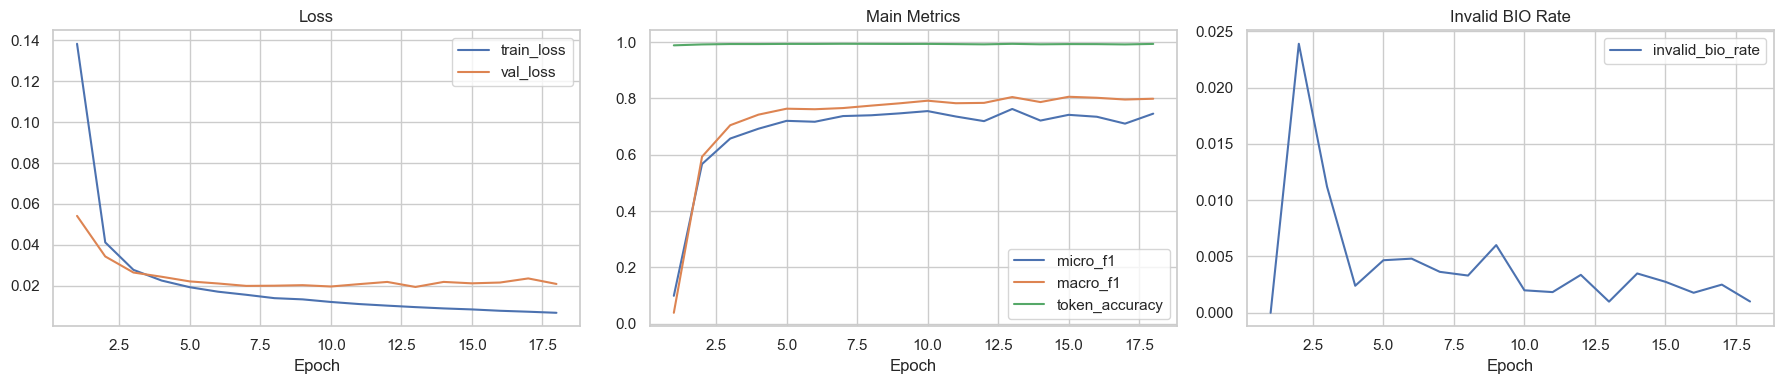

In [300]:
sns.set_theme(style="whitegrid")

epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history["train_loss"], label="train_loss")
axes[0].plot(epochs, history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["micro_f1"], label="micro_f1")
axes[1].plot(epochs, history["macro_f1"], label="macro_f1")
axes[1].plot(epochs, history["token_accuracy"], label="token_accuracy")
axes[1].set_title("Main Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs, history["invalid_bio_rate"], label="invalid_bio_rate")
axes[2].set_title("Invalid BIO Rate")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()


In [301]:
#SAVING MODEL
model_save_path = "D:\\scientific_nlp_from_scratch\\03_toxhabits_ner_bilstm\\models\\tox_habits_ner_crf_model_base.pt"
torch.save(model.state_dict(), model_save_path)


In [302]:
def get_predictions_with_metadata(model, dataloader, device, idx2tag):
    model.eval()

    rows = []

    with torch.no_grad():
        for batch in dataloader:
            batch_on_device = {
                key: value.to(device) if torch.is_tensor(value) else value
                for key, value in batch.items()
            }

            best_paths, _ = model(
                word_ids=batch_on_device["word_ids"],
                char_ids=batch_on_device["char_ids"],
                character_lengths=batch_on_device["character_lengths"],
                lengths=batch_on_device["lengths"],
                token_mask=batch_on_device["token_mask"]
            )

            gold_ids = batch["tag_ids"]
            masks = batch["token_mask"]

            for i in range(len(best_paths)):
                seq_len = int(masks[i].sum().item())

                gold_tags = [idx2tag[idx] for idx in gold_ids[i, :seq_len].tolist()]
                pred_tags = [idx2tag[idx] for idx in best_paths[i][:seq_len]]

                rows.append({
                    "document_id": batch["document_ids"][i],
                    "chunk_id": batch["chunk_ids"][i],
                    "tokens": batch["tokens"][i],
                    "offsets": batch["offsets"][i],
                    "gold_tags": gold_tags,
                    "pred_tags": pred_tags,
                })

    return rows


In [303]:
def extract_entities_with_text(tokens, offsets, tags):
    entities = []
    start_token = None
    current_label = None

    for i, tag in enumerate(tags):
        if tag == "O":
            if current_label is not None:
                entity_tokens = tokens[start_token:i]
                entity_offsets = offsets[start_token:i]
                entities.append({
                    "start_token": start_token,
                    "end_token": i,
                    "label": current_label,
                    "tokens": entity_tokens,
                    "text": " ".join(entity_tokens),
                    "start_char": entity_offsets[0][0],
                    "end_char": entity_offsets[-1][1],
                    "length_tokens": len(entity_tokens),
                })
                start_token = None
                current_label = None
            continue

        prefix, label = tag.split("-", maxsplit=1)

        if prefix == "B":
            if current_label is not None:
                entity_tokens = tokens[start_token:i]
                entity_offsets = offsets[start_token:i]
                entities.append({
                    "start_token": start_token,
                    "end_token": i,
                    "label": current_label,
                    "tokens": entity_tokens,
                    "text": " ".join(entity_tokens),
                    "start_char": entity_offsets[0][0],
                    "end_char": entity_offsets[-1][1],
                    "length_tokens": len(entity_tokens),
                })
            start_token = i
            current_label = label

        elif prefix == "I":
            if current_label is None or current_label != label:
                if current_label is not None:
                    entity_tokens = tokens[start_token:i]
                    entity_offsets = offsets[start_token:i]
                    entities.append({
                        "start_token": start_token,
                        "end_token": i,
                        "label": current_label,
                        "tokens": entity_tokens,
                        "text": " ".join(entity_tokens),
                        "start_char": entity_offsets[0][0],
                        "end_char": entity_offsets[-1][1],
                        "length_tokens": len(entity_tokens),
                    })
                start_token = i
                current_label = label

    if current_label is not None:
        entity_tokens = tokens[start_token:len(tags)]
        entity_offsets = offsets[start_token:len(tags)]
        entities.append({
            "start_token": start_token,
            "end_token": len(tags),
            "label": current_label,
            "tokens": entity_tokens,
            "text": " ".join(entity_tokens),
            "start_char": entity_offsets[0][0],
            "end_char": entity_offsets[-1][1],
            "length_tokens": len(entity_tokens),
        })

    return entities


In [304]:
def build_seen_entity_sets(train_dataset_rows):
    seen_surface_forms = set()
    seen_label_surface_forms = set()

    for row in train_dataset_rows:
        entities = extract_entities_with_text(
            tokens=row["tokens"],
            offsets=row["offsets"],
            tags=row["gold_tags"]
        )
        for ent in entities:
            text_norm = ent["text"].lower()
            seen_surface_forms.add(text_norm)
            seen_label_surface_forms.add((ent["label"], text_norm))

    return seen_surface_forms, seen_label_surface_forms


In [306]:
def analyze_errors(dataset_rows, seen_surface_forms, entity_labels):
    false_positives = []
    false_negatives = []
    boundary_errors = []
    label_confusions = []

    tp = Counter()
    fp = Counter()
    fn = Counter()

    one_word_tp = Counter()
    one_word_fp = Counter()
    one_word_fn = Counter()

    multi_word_tp = Counter()
    multi_word_fp = Counter()
    multi_word_fn = Counter()

    seen_tp = Counter()
    seen_fp = Counter()
    seen_fn = Counter()

    oov_tp = Counter()
    oov_fp = Counter()
    oov_fn = Counter()

    confusion_matrix_counter = Counter()

    for row in dataset_rows:
        gold_entities = extract_entities_with_text(
            row["tokens"], row["offsets"], row["gold_tags"]
        )
        pred_entities = extract_entities_with_text(
            row["tokens"], row["offsets"], row["pred_tags"]
        )

        gold_by_exact = {
            (e["start_token"], e["end_token"], e["label"]): e
            for e in gold_entities
        }
        pred_by_exact = {
            (e["start_token"], e["end_token"], e["label"]): e
            for e in pred_entities
        }

        gold_exact_keys = set(gold_by_exact.keys())
        pred_exact_keys = set(pred_by_exact.keys())

        matched_exact = gold_exact_keys & pred_exact_keys

        for key in matched_exact:
            ent = gold_by_exact[key]
            label = ent["label"]
            tp[label] += 1

            if ent["length_tokens"] == 1:
                one_word_tp[label] += 1
            else:
                multi_word_tp[label] += 1

            if ent["text"].lower() in seen_surface_forms:
                seen_tp[label] += 1
            else:
                oov_tp[label] += 1

        unmatched_gold = [gold_by_exact[k] for k in (gold_exact_keys - matched_exact)]
        unmatched_pred = [pred_by_exact[k] for k in (pred_exact_keys - matched_exact)]

        used_pred_ids = set()
        used_gold_ids = set()

        for gi, gold in enumerate(unmatched_gold):
            for pi, pred in enumerate(unmatched_pred):
                if pi in used_pred_ids:
                    continue

                same_span = (
                    gold["start_token"] == pred["start_token"]
                    and gold["end_token"] == pred["end_token"]
                )
                overlap = not (
                    gold["end_token"] <= pred["start_token"]
                    or pred["end_token"] <= gold["start_token"]
                )

                if same_span and gold["label"] != pred["label"]:
                    label_confusions.append({
                        "document_id": row["document_id"],
                        "chunk_id": row["chunk_id"],
                        "text": gold["text"],
                        "gold_label": gold["label"],
                        "pred_label": pred["label"],
                        "start_token": gold["start_token"],
                        "end_token": gold["end_token"],
                    })
                    confusion_matrix_counter[(gold["label"], pred["label"])] += 1
                    used_gold_ids.add(gi)
                    used_pred_ids.add(pi)
                    break

                if overlap and (
                    gold["label"] == pred["label"]
                    or gold["label"] != pred["label"]
                ):
                    boundary_errors.append({
                        "document_id": row["document_id"],
                        "chunk_id": row["chunk_id"],
                        "gold_text": gold["text"],
                        "pred_text": pred["text"],
                        "gold_label": gold["label"],
                        "pred_label": pred["label"],
                        "gold_span": (gold["start_token"], gold["end_token"]),
                        "pred_span": (pred["start_token"], pred["end_token"]),
                    })
                    used_gold_ids.add(gi)
                    used_pred_ids.add(pi)
                    break

        final_unmatched_gold = [
            gold for gi, gold in enumerate(unmatched_gold)
            if gi not in used_gold_ids
        ]
        final_unmatched_pred = [
            pred for pi, pred in enumerate(unmatched_pred)
            if pi not in used_pred_ids
        ]

        for gold in final_unmatched_gold:
            label = gold["label"]
            fn[label] += 1
            false_negatives.append({
                "document_id": row["document_id"],
                "chunk_id": row["chunk_id"],
                "text": gold["text"],
                "label": label,
                "start_token": gold["start_token"],
                "end_token": gold["end_token"],
            })

            if gold["length_tokens"] == 1:
                one_word_fn[label] += 1
            else:
                multi_word_fn[label] += 1

            if gold["text"].lower() in seen_surface_forms:
                seen_fn[label] += 1
            else:
                oov_fn[label] += 1

        for pred in final_unmatched_pred:
            label = pred["label"]
            fp[label] += 1
            false_positives.append({
                "document_id": row["document_id"],
                "chunk_id": row["chunk_id"],
                "text": pred["text"],
                "label": label,
                "start_token": pred["start_token"],
                "end_token": pred["end_token"],
            })

            if pred["length_tokens"] == 1:
                one_word_fp[label] += 1
            else:
                multi_word_fp[label] += 1

            if pred["text"].lower() in seen_surface_forms:
                seen_fp[label] += 1
            else:
                oov_fp[label] += 1

    def compute_f1(counter_tp, counter_fp, counter_fn, label):
        p = counter_tp[label] / (counter_tp[label] + counter_fp[label]) if (counter_tp[label] + counter_fp[label]) > 0 else 0.0
        r = counter_tp[label] / (counter_tp[label] + counter_fn[label]) if (counter_tp[label] + counter_fn[label]) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        return p, r, f1

    summary_rows = []
    for label in entity_labels:
        p, r, f1 = compute_f1(tp, fp, fn, label)
        p1, r1, f11 = compute_f1(one_word_tp, one_word_fp, one_word_fn, label)
        pm, rm, f1m = compute_f1(multi_word_tp, multi_word_fp, multi_word_fn, label)
        ps, rs, f1s = compute_f1(seen_tp, seen_fp, seen_fn, label)
        po, ro, f1o = compute_f1(oov_tp, oov_fp, oov_fn, label)

        summary_rows.append({
            "label": label,
            "precision": p,
            "recall": r,
            "f1": f1,
            "one_word_f1": f11,
            "multi_word_f1": f1m,
            "seen_f1": f1s,
            "oov_f1": f1o,
            "tp": tp[label],
            "fp": fp[label],
            "fn": fn[label],
        })

    summary_df = pd.DataFrame(summary_rows)

    confusion_df = pd.DataFrame(
        0,
        index=entity_labels,
        columns=entity_labels,
        dtype=int
    )
    for (gold_label, pred_label), count in confusion_matrix_counter.items():
        confusion_df.loc[gold_label, pred_label] = count

    return {
        "summary_df": summary_df,
        "false_positives_df": pd.DataFrame(false_positives),
        "false_negatives_df": pd.DataFrame(false_negatives),
        "boundary_errors_df": pd.DataFrame(boundary_errors),
        "label_confusions_df": pd.DataFrame(label_confusions),
        "confusion_df": confusion_df,
    }


In [307]:
train_rows = get_predictions_with_metadata(model, train_loader, device, idx2tag)
val_rows = get_predictions_with_metadata(model, validation_loader, device, idx2tag)
test_rows = get_predictions_with_metadata(model, test_loader, device, idx2tag)

seen_surface_forms, seen_label_surface_forms = build_seen_entity_sets(train_rows)

val_error_analysis = analyze_errors(
    dataset_rows=val_rows,
    seen_surface_forms=seen_surface_forms,
    entity_labels=ENTITY_LABELS
)

test_error_analysis = analyze_errors(
    dataset_rows=test_rows,
    seen_surface_forms=seen_surface_forms,
    entity_labels=ENTITY_LABELS
)


In [308]:
print("VALIDATION SUMMARY")
display(val_error_analysis["summary_df"].round(4))

print("TEST SUMMARY")
display(test_error_analysis["summary_df"].round(4))


VALIDATION SUMMARY


,label,precision,recall,f1,one_word_f1,multi_word_f1,seen_f1,oov_f1,tp,fp,fn
0,Drug,0.6949,0.7842,0.7368,0.7444,0.6866,0.8035,0.1524,378,166,104
1,Alcohol,0.7868,0.8295,0.8075,0.8061,1.0000,0.8249,0.2500,107,29,22
2,Tobacco,0.7857,0.8148,0.8000,0.8049,0.0000,0.7975,1.0000,66,18,15
3,Cannabis,0.9268,0.9383,0.9325,0.9325,0.0000,0.9500,0.0000,76,6,5


TEST SUMMARY


,label,precision,recall,f1,one_word_f1,multi_word_f1,seen_f1,oov_f1,tp,fp,fn
0,Drug,0.7280,0.7820,0.7541,0.7640,0.6733,0.8128,0.3243,348,130,97
1,Alcohol,0.7333,0.8871,0.8029,0.8000,0.8889,0.8059,0.0000,110,40,14
2,Tobacco,0.8442,0.8784,0.8609,0.8667,0.0000,0.8725,0.0000,65,12,9
3,Cannabis,0.9429,0.9851,0.9635,0.9635,0.0000,0.9635,0.0000,66,4,1


In [309]:
print("Top false positives")
display(
    test_error_analysis["false_positives_df"]
    .value_counts(["label", "text"])
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)

print("Top false negatives")
display(
    test_error_analysis["false_negatives_df"]
    .value_counts(["label", "text"])
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)

print("Top boundary errors")
display(
    test_error_analysis["boundary_errors_df"]
    .value_counts(["gold_label", "pred_label", "gold_text", "pred_text"])
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)

print("Top label confusions")
display(
    test_error_analysis["label_confusions_df"]
    .value_counts(["gold_label", "pred_label", "text"])
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)


Top false positives


,label,text,count
0,Alcohol,alcohol,17
1,Drug,consumo,9
2,Drug,benzodiacepinas,6
3,Tobacco,fumador,6
4,Drug,metanfetamina,5
5,Alcohol,beber,4
6,Drug,desintoxicación,4
7,Drug,metadona,4
8,Drug,buprenorfina / naloxona,4
9,Drug,heroína,3


Top false negatives


,label,text,count
0,Drug,abstinencia,10
1,Drug,buprenorfina / naloxona,4
2,Drug,droga,4
3,Tobacco,cigarrillos,4
4,Alcohol,beber,3
5,Drug,tóxicos,3
6,Drug,consumir,2
7,Drug,colas,2
8,Drug,consumo,2
9,Alcohol,combinados,2


Top boundary errors


,gold_label,pred_label,gold_text,pred_text,count
0,Cannabis,Cannabis,hachís ( porros ),porros,1
1,Drug,Alcohol,bebida energética con alto contenido en cafeín...,bebida,1
2,Drug,Alcohol,bebidas energéticas,bebidas,1
3,Drug,Drug,MDMA,"MDMA o "" Molly",1
4,Drug,Drug,"MDMA ( 3,4-metilendioximetanfetamina )","MDMA ( 3,4-metilendioximetanfetamina",1
5,Drug,Drug,clorhidrato de cocaína,cocaína,1
6,Drug,Drug,dibutilona ( bk-DMBDB ),bk-DMBDB,1
7,Drug,Drug,drogas,policonsumo de drogas,1
8,Drug,Drug,estimulantes ( centramina ),centramina,1
9,Drug,Drug,fenciclidina ( PCP ),PCP,1


Top label confusions


,gold_label,pred_label,text,count
0,Alcohol,Drug,coca-cola,1


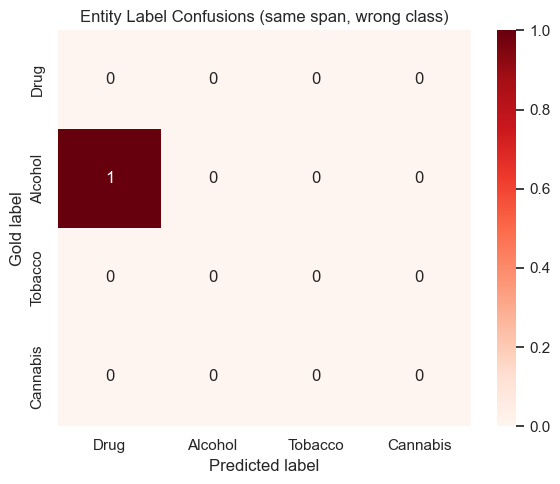

In [310]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    test_error_analysis["confusion_df"],
    annot=True,
    fmt="d",
    cmap="Reds"
)
plt.title("Entity Label Confusions (same span, wrong class)")
plt.xlabel("Predicted label")
plt.ylabel("Gold label")
plt.tight_layout()
plt.show()


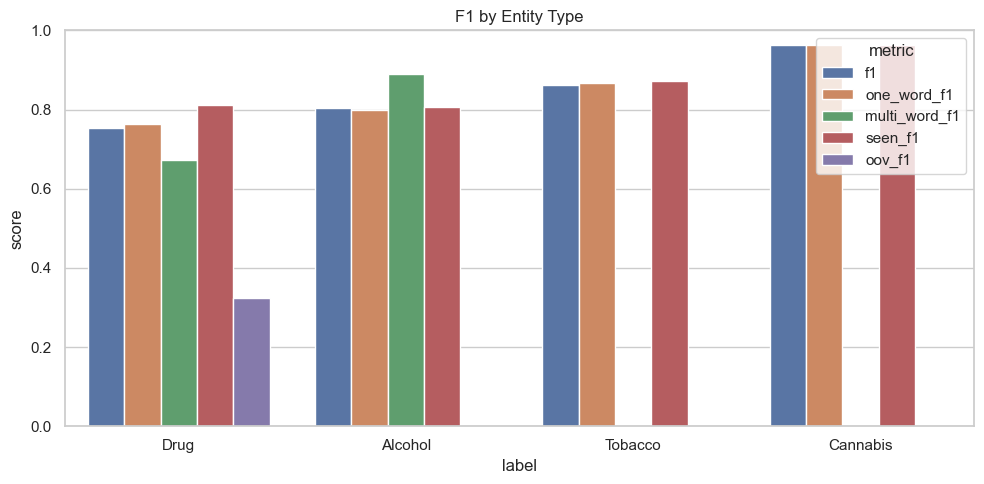

In [311]:
plot_df = test_error_analysis["summary_df"].copy()
plot_df = plot_df.melt(
    id_vars="label",
    value_vars=["f1", "one_word_f1", "multi_word_f1", "seen_f1", "oov_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="label", y="score", hue="metric")
plt.title("F1 by Entity Type")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
